[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E2_Multivariate_Demand_RNN.ipynb)

# Multivariate RNN: Electricity Demand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Drop the lag columns. Hand the RNN the raw multivariate sequence as a **3-D tensor** `(samples, look-back, features)` - weather and clock on the left, **demand as the last column** - and let it decide what to remember. SimpleRNN first, then the one-word LSTM swap, then a stacked model with `return_sequences=True`, always scored against the dumb baselines. A classification head (peak hour or not?) closes the notebook so you see both output types on one dataset.

*Energy-track version of the occupancy RNN notebook.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 9B — Multivariate RNN Pt 1: split_sequences, column order, the 3-D tensor
- Multivariate differs from univariate only in prep: covariates on the left, target as the LAST column - and the target's own history stays in X. split_sequences takes y from the right.
- Look-back 24 -> (8736, 24, 8) train tensor. Walk the shape: samples, look-back, features. Inherit n_steps/n_features from the shape.
- SimpleRNN(30) with a LINEAR head (regression, MW) - params (8+30)*30+30 = 1,170 plus 31 for the head.
- Scale on train only; a separate scaler for the target so you can inverse_transform back to megawatts.
- Read the MAE against persistence (129) and seasonal naive (227): SimpleRNN ~48 MW, because the target's own past is in the window. That's the whole point of the column-order slide.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Prep: `split_sequences` and the 3-D tensor

Scale on train only. `split_sequences` takes the inputs from **every** column - demand's own past included - and the target from the last column at the **next** step.

In [4]:
def split_sequences(seqs, n_steps):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -1])   # inputs = EVERY column (demand's own past included); target = last col, NEXT step
    return np.array(X), np.array(y)

n_steps = 24
sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # a separate scaler for the target so we can get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()   # test target in MW
print("train tensor:", X_train.shape, "-> (samples, look-back, features) | test:", X_test.shape)

train tensor: (8736, 24, 8) -> (samples, look-back, features) | test: (8736, 24, 8)


## SimpleRNN with a linear head

In [5]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

rnn = Sequential([SimpleRNN(30, input_shape=(n_steps, n_features)), Dense(1)])   # linear output: we predict megawatts
rnn.compile(optimizer="adam", loss="mse", metrics=["mae"])
rnn.summary()
hist = rnn.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,201 (4.69 KB)

 Trainable params: 1,201 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6:24 4s/step - loss: 0.5564 - mae: 0.7191

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1467 - mae: 0.3070 

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0997 - mae: 0.2442

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0777 - mae: 0.2120

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0642 - mae: 0.1879

 46/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0566 - mae: 0.1746

 54/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0509 - mae: 0.1647

 62/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0463 - mae: 0.1561

 70/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0425 - mae: 0.1487

 77/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0398 - mae: 0.1433

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0375 - mae: 0.1387

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0357 - mae: 0.1348

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0336 - mae: 0.1303

106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0318 - mae: 0.1264

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0311 - mae: 0.1248 - val_loss: 0.0082 - val_mae: 0.0746


Epoch 2/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0089 - mae: 0.0786

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 - mae: 0.0717 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0081 - mae: 0.0699

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - mae: 0.0698

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - mae: 0.0684

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - mae: 0.0680

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0074 - mae: 0.0669

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - mae: 0.0659

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 - mae: 0.0650

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068 - mae: 0.0642

 96/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067 - mae: 0.0637

105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - mae: 0.0629

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0064 - mae: 0.0625 - val_loss: 0.0042 - val_mae: 0.0531


Epoch 3/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 45s 416ms/step - loss: 0.0046 - mae: 0.0561

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 - mae: 0.0533   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - mae: 0.0518

 27/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mae: 0.0516

 35/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mae: 0.0519

 45/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0514

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0512

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - mae: 0.0506

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - mae: 0.0501

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0497

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - mae: 0.0493

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - mae: 0.0487

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - mae: 0.0484

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039 - mae: 0.0484 - val_loss: 0.0027 - val_mae: 0.0420


Epoch 4/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0029 - mae: 0.0446

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - mae: 0.0428 

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0421

 26/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0421

 33/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - mae: 0.0421

 42/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0424

 50/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - mae: 0.0423

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - mae: 0.0419

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - mae: 0.0415

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - mae: 0.0412

 89/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - mae: 0.0409

 99/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - mae: 0.0405

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - mae: 0.0402

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - mae: 0.0402 - val_loss: 0.0020 - val_mae: 0.0354


Epoch 5/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - loss: 0.0020 - mae: 0.0377

  8/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027 - mae: 0.0370   

 17/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - mae: 0.0362

 23/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0363

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0359

 40/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - mae: 0.0365

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0364

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0363

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - mae: 0.0359

 76/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - mae: 0.0356

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - mae: 0.0355

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - mae: 0.0354

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mae: 0.0351

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mae: 0.0350

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021 - mae: 0.0350 - val_loss: 0.0016 - val_mae: 0.0312


Epoch 6/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0015 - mae: 0.0332

  8/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0329 

 17/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0321

 25/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0323

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - mae: 0.0318

 40/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - mae: 0.0324

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - mae: 0.0324

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - mae: 0.0323

 67/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - mae: 0.0319

 76/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - mae: 0.0317

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0317

 94/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0316

103/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0313

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017 - mae: 0.0313 - val_loss: 0.0013 - val_mae: 0.0280


Epoch 7/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0012 - mae: 0.0293

  9/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0294 

 16/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0293

 24/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0293

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0292

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0293

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0295

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0293

 65/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0290

 75/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mae: 0.0288

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0288

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0288

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0286

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0285

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - mae: 0.0285 - val_loss: 0.0011 - val_mae: 0.0256


Epoch 8/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 40s 369ms/step - loss: 9.7036e-04 - mae: 0.0261

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0272       

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0268

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0269

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0270

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0272

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0270

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0268

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0267

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0266

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0267

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0265

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0264

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - mae: 0.0264 - val_loss: 9.5864e-04 - val_mae: 0.0240


Epoch 9/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 8.2678e-04 - mae: 0.0238

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0252      

 14/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mae: 0.0246

 22/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0249

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0251

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0250

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0254

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0252

 65/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0250

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0248

 81/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - mae: 0.0248

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - mae: 0.0249

 99/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - mae: 0.0248

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - mae: 0.0247

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - mae: 0.0247 - val_loss: 8.5831e-04 - val_mae: 0.0228


Epoch 10/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 7.2906e-04 - mae: 0.0221

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - mae: 0.0237     

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7291e-04 - mae: 0.0234

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.7868e-04 - mae: 0.0236

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.9609e-04 - mae: 0.0236

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - mae: 0.0238    

 56/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.7800e-04 - mae: 0.0237

 65/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.5851e-04 - mae: 0.0235

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4825e-04 - mae: 0.0233

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3996e-04 - mae: 0.0233

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4615e-04 - mae: 0.0234

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3435e-04 - mae: 0.0233

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2509e-04 - mae: 0.0232

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.2509e-04 - mae: 0.0232 - val_loss: 7.7826e-04 - val_mae: 0.0218


Epoch 11/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 6.6125e-04 - mae: 0.0209

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0331e-04 - mae: 0.0224 

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.6592e-04 - mae: 0.0220

 27/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.6052e-04 - mae: 0.0222

 34/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.6011e-04 - mae: 0.0221

 42/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9600e-04 - mae: 0.0225

 50/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.8478e-04 - mae: 0.0225

 58/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.6456e-04 - mae: 0.0224

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5430e-04 - mae: 0.0222

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.4343e-04 - mae: 0.0221

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.4075e-04 - mae: 0.0221

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.4737e-04 - mae: 0.0222

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3819e-04 - mae: 0.0221

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.2948e-04 - mae: 0.0221

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.2948e-04 - mae: 0.0221 - val_loss: 7.1508e-04 - val_mae: 0.0210


Epoch 12/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 6.1260e-04 - mae: 0.0199

  9/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.2136e-04 - mae: 0.0213 

 17/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.8896e-04 - mae: 0.0210

 24/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.8740e-04 - mae: 0.0212

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7988e-04 - mae: 0.0212

 40/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1033e-04 - mae: 0.0214

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.0610e-04 - mae: 0.0215

 56/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.8944e-04 - mae: 0.0214

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7701e-04 - mae: 0.0212

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.6507e-04 - mae: 0.0211

 81/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.6056e-04 - mae: 0.0211

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6433e-04 - mae: 0.0212

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5934e-04 - mae: 0.0211

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5217e-04 - mae: 0.0210

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.5169e-04 - mae: 0.0210 - val_loss: 6.6485e-04 - val_mae: 0.0203


Epoch 13/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 5.7461e-04 - mae: 0.0191

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.6449e-04 - mae: 0.0206 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2013e-04 - mae: 0.0202

 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1270e-04 - mae: 0.0203

 41/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3770e-04 - mae: 0.0205

 51/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2533e-04 - mae: 0.0205

 61/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1112e-04 - mae: 0.0203

 70/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9695e-04 - mae: 0.0201

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9210e-04 - mae: 0.0201

 89/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9761e-04 - mae: 0.0203

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9641e-04 - mae: 0.0202

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8733e-04 - mae: 0.0201

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.8632e-04 - mae: 0.0201 - val_loss: 6.2177e-04 - val_mae: 0.0197


Epoch 14/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 5.3813e-04 - mae: 0.0183

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.0174e-04 - mae: 0.0198 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6186e-04 - mae: 0.0194

 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5357e-04 - mae: 0.0195

 42/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7310e-04 - mae: 0.0197

 53/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5726e-04 - mae: 0.0196

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4947e-04 - mae: 0.0195

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3688e-04 - mae: 0.0193

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3931e-04 - mae: 0.0194

 95/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4270e-04 - mae: 0.0195

106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3347e-04 - mae: 0.0194

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3024e-04 - mae: 0.0193 - val_loss: 5.8034e-04 - val_mae: 0.0191


Epoch 15/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 4.9567e-04 - mae: 0.0174

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4354e-04 - mae: 0.0190 

 22/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0657e-04 - mae: 0.0187

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0074e-04 - mae: 0.0187

 42/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1755e-04 - mae: 0.0189

 52/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0921e-04 - mae: 0.0189

 62/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9830e-04 - mae: 0.0187

 72/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8924e-04 - mae: 0.0186

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8651e-04 - mae: 0.0186

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9305e-04 - mae: 0.0187

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8795e-04 - mae: 0.0187

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8223e-04 - mae: 0.0186

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8204e-04 - mae: 0.0186 - val_loss: 5.3901e-04 - val_mae: 0.0183


Epoch 16/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 4.4659e-04 - mae: 0.0164

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7526e-04 - mae: 0.0182 

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5958e-04 - mae: 0.0179

 28/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5501e-04 - mae: 0.0180

 35/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5605e-04 - mae: 0.0180

 44/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.6494e-04 - mae: 0.0181

 54/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5786e-04 - mae: 0.0181

 63/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5012e-04 - mae: 0.0180

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4546e-04 - mae: 0.0179

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4496e-04 - mae: 0.0180

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5067e-04 - mae: 0.0181

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4805e-04 - mae: 0.0181

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4139e-04 - mae: 0.0180

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.4058e-04 - mae: 0.0180 - val_loss: 4.9915e-04 - val_mae: 0.0176


Epoch 17/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 3.9389e-04 - mae: 0.0153

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3749e-04 - mae: 0.0175 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1448e-04 - mae: 0.0172

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1299e-04 - mae: 0.0173

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2051e-04 - mae: 0.0173

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2309e-04 - mae: 0.0175

 58/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1526e-04 - mae: 0.0175

 67/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1114e-04 - mae: 0.0174

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0574e-04 - mae: 0.0173

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0967e-04 - mae: 0.0174

 94/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1412e-04 - mae: 0.0175

104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0841e-04 - mae: 0.0174

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0450e-04 - mae: 0.0174 - val_loss: 4.6422e-04 - val_mae: 0.0168


Epoch 18/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 49s 455ms/step - loss: 3.4300e-04 - mae: 0.0142

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8398e-04 - mae: 0.0167   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7543e-04 - mae: 0.0165

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7540e-04 - mae: 0.0167

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8366e-04 - mae: 0.0167

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8662e-04 - mae: 0.0169

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7936e-04 - mae: 0.0169

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7687e-04 - mae: 0.0168

 78/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7086e-04 - mae: 0.0167

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7879e-04 - mae: 0.0169

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7950e-04 - mae: 0.0169

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7486e-04 - mae: 0.0169

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7282e-04 - mae: 0.0168 - val_loss: 4.3833e-04 - val_mae: 0.0163


Epoch 19/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 50s 468ms/step - loss: 3.0202e-04 - mae: 0.0135

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4977e-04 - mae: 0.0160   

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4278e-04 - mae: 0.0160

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4610e-04 - mae: 0.0162

 40/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5723e-04 - mae: 0.0163

 50/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5558e-04 - mae: 0.0164

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5274e-04 - mae: 0.0164

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4885e-04 - mae: 0.0163

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4481e-04 - mae: 0.0163

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4640e-04 - mae: 0.0163

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5216e-04 - mae: 0.0164

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4860e-04 - mae: 0.0164

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4520e-04 - mae: 0.0164

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.4520e-04 - mae: 0.0164 - val_loss: 4.2092e-04 - val_mae: 0.0159


Epoch 20/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 2.7419e-04 - mae: 0.0133

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1346e-04 - mae: 0.0155 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1026e-04 - mae: 0.0154

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1809e-04 - mae: 0.0157

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2456e-04 - mae: 0.0157

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2806e-04 - mae: 0.0159

 58/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2464e-04 - mae: 0.0159

 68/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2346e-04 - mae: 0.0158

 77/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1858e-04 - mae: 0.0158

 86/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2410e-04 - mae: 0.0159

 95/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2776e-04 - mae: 0.0160

105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2326e-04 - mae: 0.0159

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.2106e-04 - mae: 0.0159 - val_loss: 4.0654e-04 - val_mae: 0.0156


Epoch 21/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 49s 454ms/step - loss: 2.5510e-04 - mae: 0.0131

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8997e-04 - mae: 0.0150   

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9021e-04 - mae: 0.0151

 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9482e-04 - mae: 0.0153

 41/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0596e-04 - mae: 0.0154

 51/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0289e-04 - mae: 0.0155

 60/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0278e-04 - mae: 0.0155

 70/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9989e-04 - mae: 0.0154

 80/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9917e-04 - mae: 0.0154

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0488e-04 - mae: 0.0156

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0138e-04 - mae: 0.0155

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9979e-04 - mae: 0.0155

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.9939e-04 - mae: 0.0155 - val_loss: 3.8977e-04 - val_mae: 0.0153


Epoch 22/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 2.3848e-04 - mae: 0.0127

  9/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6948e-04 - mae: 0.0148 

 18/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7089e-04 - mae: 0.0147

 26/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7435e-04 - mae: 0.0149

 35/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7566e-04 - mae: 0.0149

 44/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8297e-04 - mae: 0.0150

 53/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8029e-04 - mae: 0.0150

 62/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8123e-04 - mae: 0.0150

 71/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8021e-04 - mae: 0.0150

 81/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8031e-04 - mae: 0.0151

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8466e-04 - mae: 0.0152

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8105e-04 - mae: 0.0152

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7957e-04 - mae: 0.0151

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7957e-04 - mae: 0.0151 - val_loss: 3.7019e-04 - val_mae: 0.0150


Epoch 23/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 2.2210e-04 - mae: 0.0122

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5129e-04 - mae: 0.0143 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5452e-04 - mae: 0.0144

 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5863e-04 - mae: 0.0146

 41/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6758e-04 - mae: 0.0147

 51/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6441e-04 - mae: 0.0147

 61/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6493e-04 - mae: 0.0147

 72/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6487e-04 - mae: 0.0147

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6305e-04 - mae: 0.0147

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6715e-04 - mae: 0.0149

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6279e-04 - mae: 0.0148

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6171e-04 - mae: 0.0148 - val_loss: 3.5150e-04 - val_mae: 0.0146


Epoch 24/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 2.0786e-04 - mae: 0.0116

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3588e-04 - mae: 0.0141 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3670e-04 - mae: 0.0141

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3959e-04 - mae: 0.0142

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4916e-04 - mae: 0.0143

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5257e-04 - mae: 0.0145

 56/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5051e-04 - mae: 0.0145

 65/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4971e-04 - mae: 0.0144

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4862e-04 - mae: 0.0144

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4802e-04 - mae: 0.0144

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5117e-04 - mae: 0.0145

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4702e-04 - mae: 0.0145

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4585e-04 - mae: 0.0144 - val_loss: 3.3601e-04 - val_mae: 0.0144


Epoch 25/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 1.9699e-04 - mae: 0.0112

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2139e-04 - mae: 0.0138 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2297e-04 - mae: 0.0138

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2631e-04 - mae: 0.0139

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3533e-04 - mae: 0.0140

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3639e-04 - mae: 0.0141

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3575e-04 - mae: 0.0141

 68/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3636e-04 - mae: 0.0141

 78/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3437e-04 - mae: 0.0141

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3505e-04 - mae: 0.0142

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3429e-04 - mae: 0.0142

106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3250e-04 - mae: 0.0141

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.3169e-04 - mae: 0.0141 - val_loss: 3.2336e-04 - val_mae: 0.0141


Epoch 26/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 1.8865e-04 - mae: 0.0109

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0740e-04 - mae: 0.0135 

 22/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1535e-04 - mae: 0.0136

 33/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1693e-04 - mae: 0.0137

 44/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2451e-04 - mae: 0.0139

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2126e-04 - mae: 0.0139

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2389e-04 - mae: 0.0138

 76/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2136e-04 - mae: 0.0138

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2203e-04 - mae: 0.0139

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2351e-04 - mae: 0.0139

103/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2000e-04 - mae: 0.0139

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.1893e-04 - mae: 0.0138 - val_loss: 3.1270e-04 - val_mae: 0.0139


Epoch 27/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 1.8188e-04 - mae: 0.0108

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9432e-04 - mae: 0.0132 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0091e-04 - mae: 0.0133

 31/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0728e-04 - mae: 0.0135

 42/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1470e-04 - mae: 0.0136

 52/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1082e-04 - mae: 0.0136

 62/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1031e-04 - mae: 0.0135

 72/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0969e-04 - mae: 0.0135

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0945e-04 - mae: 0.0136

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1147e-04 - mae: 0.0136

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0844e-04 - mae: 0.0136

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0745e-04 - mae: 0.0136 - val_loss: 3.0412e-04 - val_mae: 0.0138


Epoch 28/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 1.7710e-04 - mae: 0.0106

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8278e-04 - mae: 0.0130 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8989e-04 - mae: 0.0130

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9430e-04 - mae: 0.0132

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0075e-04 - mae: 0.0133

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0040e-04 - mae: 0.0133

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9889e-04 - mae: 0.0133

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9811e-04 - mae: 0.0132

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9645e-04 - mae: 0.0133

 89/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0014e-04 - mae: 0.0134

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9864e-04 - mae: 0.0134

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9719e-04 - mae: 0.0133

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.9701e-04 - mae: 0.0133 - val_loss: 2.9772e-04 - val_mae: 0.0136


Epoch 29/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 1.7484e-04 - mae: 0.0107

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7257e-04 - mae: 0.0127 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7973e-04 - mae: 0.0127

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8055e-04 - mae: 0.0128

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9036e-04 - mae: 0.0130

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8968e-04 - mae: 0.0131

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8768e-04 - mae: 0.0130

 68/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8698e-04 - mae: 0.0130

 76/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8382e-04 - mae: 0.0129

 86/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8795e-04 - mae: 0.0131

 96/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9004e-04 - mae: 0.0132

106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8765e-04 - mae: 0.0131

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8711e-04 - mae: 0.0131 - val_loss: 2.9171e-04 - val_mae: 0.0135


Epoch 30/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 1.7358e-04 - mae: 0.0107

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6709e-04 - mae: 0.0126   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6750e-04 - mae: 0.0124

 27/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7374e-04 - mae: 0.0126

 33/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7400e-04 - mae: 0.0127

 41/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8119e-04 - mae: 0.0128

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7886e-04 - mae: 0.0128

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7698e-04 - mae: 0.0128

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7701e-04 - mae: 0.0127

 75/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7214e-04 - mae: 0.0126

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7644e-04 - mae: 0.0128

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8069e-04 - mae: 0.0129

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7868e-04 - mae: 0.0129

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7738e-04 - mae: 0.0129

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7738e-04 - mae: 0.0129 - val_loss: 2.8308e-04 - val_mae: 0.0133


Epoch 31/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 1.7004e-04 - mae: 0.0107

  8/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3731e-04 - mae: 0.0119  

 16/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5418e-04 - mae: 0.0121

 25/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6335e-04 - mae: 0.0123

 33/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6290e-04 - mae: 0.0124

 41/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6976e-04 - mae: 0.0126

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6770e-04 - mae: 0.0125

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6624e-04 - mae: 0.0125

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6574e-04 - mae: 0.0124

 71/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6323e-04 - mae: 0.0124

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6262e-04 - mae: 0.0124

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6783e-04 - mae: 0.0126

 96/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7128e-04 - mae: 0.0127

105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6930e-04 - mae: 0.0127

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6792e-04 - mae: 0.0126 - val_loss: 2.7053e-04 - val_mae: 0.0129


Epoch 32/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 1.6241e-04 - mae: 0.0105

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4571e-04 - mae: 0.0119 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4592e-04 - mae: 0.0118

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4824e-04 - mae: 0.0120

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5701e-04 - mae: 0.0122

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5655e-04 - mae: 0.0123

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5546e-04 - mae: 0.0122

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5471e-04 - mae: 0.0122

 79/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5255e-04 - mae: 0.0122

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5815e-04 - mae: 0.0123

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6197e-04 - mae: 0.0125

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5964e-04 - mae: 0.0124

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5899e-04 - mae: 0.0124 - val_loss: 2.5537e-04 - val_mae: 0.0125


Epoch 33/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 1.5165e-04 - mae: 0.0102

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3401e-04 - mae: 0.0116 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3530e-04 - mae: 0.0115

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4098e-04 - mae: 0.0118

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4613e-04 - mae: 0.0119

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4669e-04 - mae: 0.0120

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4586e-04 - mae: 0.0120

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4629e-04 - mae: 0.0119

 75/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4176e-04 - mae: 0.0119

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4789e-04 - mae: 0.0121

 94/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5370e-04 - mae: 0.0122

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5271e-04 - mae: 0.0122

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5067e-04 - mae: 0.0122 - val_loss: 2.4033e-04 - val_mae: 0.0120


Epoch 34/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 1.4040e-04 - mae: 0.0098

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2242e-04 - mae: 0.0112 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2537e-04 - mae: 0.0113

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2777e-04 - mae: 0.0114

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3686e-04 - mae: 0.0117

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3786e-04 - mae: 0.0118

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3598e-04 - mae: 0.0117

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3694e-04 - mae: 0.0117

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3401e-04 - mae: 0.0117

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3743e-04 - mae: 0.0118

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4592e-04 - mae: 0.0120

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4487e-04 - mae: 0.0120

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4377e-04 - mae: 0.0120

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4287e-04 - mae: 0.0120 - val_loss: 2.2830e-04 - val_mae: 0.0116


Epoch 35/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 1.3161e-04 - mae: 0.0094

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1157e-04 - mae: 0.0109 

 18/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1721e-04 - mae: 0.0111

 28/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2130e-04 - mae: 0.0113

 37/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2839e-04 - mae: 0.0114

 46/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2946e-04 - mae: 0.0116

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2801e-04 - mae: 0.0115

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2907e-04 - mae: 0.0115

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2681e-04 - mae: 0.0115

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3015e-04 - mae: 0.0116

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3876e-04 - mae: 0.0119

103/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3783e-04 - mae: 0.0119

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3562e-04 - mae: 0.0118 - val_loss: 2.2048e-04 - val_mae: 0.0113


Epoch 36/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - loss: 1.2664e-04 - mae: 0.0092

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0213e-04 - mae: 0.0107   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0913e-04 - mae: 0.0108

 27/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1529e-04 - mae: 0.0111

 36/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2128e-04 - mae: 0.0113

 45/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2237e-04 - mae: 0.0114

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2095e-04 - mae: 0.0114

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2209e-04 - mae: 0.0113

 74/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1938e-04 - mae: 0.0113

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2338e-04 - mae: 0.0114

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3183e-04 - mae: 0.0117

103/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3106e-04 - mae: 0.0117

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2901e-04 - mae: 0.0116 - val_loss: 2.1555e-04 - val_mae: 0.0111


Epoch 37/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 1.2421e-04 - mae: 0.0090

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9356e-04 - mae: 0.0105 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0215e-04 - mae: 0.0107

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0553e-04 - mae: 0.0109

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1435e-04 - mae: 0.0111

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1512e-04 - mae: 0.0112

 55/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1440e-04 - mae: 0.0112

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1569e-04 - mae: 0.0111

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1371e-04 - mae: 0.0111

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1634e-04 - mae: 0.0112

 91/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2432e-04 - mae: 0.0115

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2415e-04 - mae: 0.0115

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2288e-04 - mae: 0.0115

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2288e-04 - mae: 0.0115 - val_loss: 2.1117e-04 - val_mae: 0.0110


Epoch 38/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 1.2193e-04 - mae: 0.0089

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8759e-04 - mae: 0.0103 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9900e-04 - mae: 0.0106

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0227e-04 - mae: 0.0108

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0752e-04 - mae: 0.0109

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0752e-04 - mae: 0.0110

 58/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0847e-04 - mae: 0.0110

 68/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0993e-04 - mae: 0.0110

 77/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0662e-04 - mae: 0.0109

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1246e-04 - mae: 0.0112

 94/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1868e-04 - mae: 0.0113

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1829e-04 - mae: 0.0113

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1704e-04 - mae: 0.0113

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1694e-04 - mae: 0.0113 - val_loss: 2.0573e-04 - val_mae: 0.0108


Epoch 39/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 1.1804e-04 - mae: 0.0087

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8281e-04 - mae: 0.0102 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9376e-04 - mae: 0.0104

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9388e-04 - mae: 0.0105

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0145e-04 - mae: 0.0108

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0162e-04 - mae: 0.0108

 58/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0234e-04 - mae: 0.0108

 68/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0398e-04 - mae: 0.0108

 78/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0096e-04 - mae: 0.0108

 88/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0841e-04 - mae: 0.0110

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1229e-04 - mae: 0.0112

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1198e-04 - mae: 0.0112

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.1112e-04 - mae: 0.0111 - val_loss: 1.9923e-04 - val_mae: 0.0106


Epoch 40/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 1.1245e-04 - mae: 0.0085

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8090e-04 - mae: 0.0101 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8678e-04 - mae: 0.0102

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8862e-04 - mae: 0.0104

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9546e-04 - mae: 0.0106

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9623e-04 - mae: 0.0107

 56/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9698e-04 - mae: 0.0107

 63/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9675e-04 - mae: 0.0106

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9645e-04 - mae: 0.0106

 83/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9834e-04 - mae: 0.0107

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0663e-04 - mae: 0.0110

100/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0567e-04 - mae: 0.0110

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0574e-04 - mae: 0.0110

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0563e-04 - mae: 0.0110 - val_loss: 1.9306e-04 - val_mae: 0.0104


Epoch 41/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 1.0671e-04 - mae: 0.0085

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7691e-04 - mae: 0.0100 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8317e-04 - mae: 0.0101

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8400e-04 - mae: 0.0102

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9021e-04 - mae: 0.0104

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9043e-04 - mae: 0.0105

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9185e-04 - mae: 0.0105

 67/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9278e-04 - mae: 0.0105

 77/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9044e-04 - mae: 0.0105

 87/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9516e-04 - mae: 0.0107

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0108e-04 - mae: 0.0108

108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0097e-04 - mae: 0.0108

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0080e-04 - mae: 0.0108 - val_loss: 1.8876e-04 - val_mae: 0.0103


Epoch 42/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 1.0257e-04 - mae: 0.0084

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7578e-04 - mae: 0.0100 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8044e-04 - mae: 0.0100

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8021e-04 - mae: 0.0101

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8568e-04 - mae: 0.0103

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8548e-04 - mae: 0.0103

 59/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8700e-04 - mae: 0.0104

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8831e-04 - mae: 0.0104

 78/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8624e-04 - mae: 0.0104

 88/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9278e-04 - mae: 0.0106

 97/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9660e-04 - mae: 0.0107

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9709e-04 - mae: 0.0107

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.9669e-04 - mae: 0.0107 - val_loss: 1.8700e-04 - val_mae: 0.0103


Epoch 43/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 1.0088e-04 - mae: 0.0084

 11/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7554e-04 - mae: 0.0100 

 21/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8054e-04 - mae: 0.0100

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7926e-04 - mae: 0.0101

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8222e-04 - mae: 0.0102

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8224e-04 - mae: 0.0102

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8365e-04 - mae: 0.0103

 67/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8437e-04 - mae: 0.0103

 76/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8211e-04 - mae: 0.0102

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8643e-04 - mae: 0.0104

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9288e-04 - mae: 0.0106

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9254e-04 - mae: 0.0106

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9313e-04 - mae: 0.0106

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.9313e-04 - mae: 0.0106 - val_loss: 1.8753e-04 - val_mae: 0.0103


Epoch 44/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - loss: 1.0139e-04 - mae: 0.0085

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7997e-04 - mae: 0.0101   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7742e-04 - mae: 0.0100

 28/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7634e-04 - mae: 0.0100

 37/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7982e-04 - mae: 0.0101

 45/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7953e-04 - mae: 0.0102

 53/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7854e-04 - mae: 0.0101

 63/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7989e-04 - mae: 0.0101

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8012e-04 - mae: 0.0102

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8235e-04 - mae: 0.0103

 90/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8807e-04 - mae: 0.0104

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8902e-04 - mae: 0.0105

105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8990e-04 - mae: 0.0105

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8990e-04 - mae: 0.0105 - val_loss: 1.8941e-04 - val_mae: 0.0104


Epoch 45/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 1.0313e-04 - mae: 0.0086

  8/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6902e-04 - mae: 0.0099  

 15/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7302e-04 - mae: 0.0099

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7581e-04 - mae: 0.0099

 29/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7303e-04 - mae: 0.0099

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7731e-04 - mae: 0.0101

 47/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7660e-04 - mae: 0.0101

 54/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7588e-04 - mae: 0.0101

 61/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7749e-04 - mae: 0.0101

 69/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7827e-04 - mae: 0.0101

 77/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7665e-04 - mae: 0.0101

 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8006e-04 - mae: 0.0102

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8573e-04 - mae: 0.0104

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8587e-04 - mae: 0.0104

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8698e-04 - mae: 0.0105

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8686e-04 - mae: 0.0105 - val_loss: 1.9168e-04 - val_mae: 0.0105


Epoch 46/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - loss: 1.0512e-04 - mae: 0.0087

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8101e-04 - mae: 0.0102   

 19/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7484e-04 - mae: 0.0099

 28/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7247e-04 - mae: 0.0099

 37/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7513e-04 - mae: 0.0100

 44/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7343e-04 - mae: 0.0100

 53/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7280e-04 - mae: 0.0100

 62/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7492e-04 - mae: 0.0100

 72/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7453e-04 - mae: 0.0100

 81/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7571e-04 - mae: 0.0101

 89/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8002e-04 - mae: 0.0102

 98/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8277e-04 - mae: 0.0103

106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8412e-04 - mae: 0.0104

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8392e-04 - mae: 0.0104 - val_loss: 1.9378e-04 - val_mae: 0.0106


Epoch 47/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - loss: 1.0677e-04 - mae: 0.0088

  9/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8474e-04 - mae: 0.0104   

 17/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7237e-04 - mae: 0.0099

 26/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7226e-04 - mae: 0.0099

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7246e-04 - mae: 0.0100

 39/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7226e-04 - mae: 0.0100

 48/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7076e-04 - mae: 0.0099

 56/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7155e-04 - mae: 0.0100

 63/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7117e-04 - mae: 0.0099

 72/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7174e-04 - mae: 0.0100

 80/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7277e-04 - mae: 0.0100

 88/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7658e-04 - mae: 0.0101

 96/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7994e-04 - mae: 0.0102

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7989e-04 - mae: 0.0103

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8103e-04 - mae: 0.0103 - val_loss: 1.9549e-04 - val_mae: 0.0107


Epoch 48/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 1.0791e-04 - mae: 0.0089

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8046e-04 - mae: 0.0102 

 20/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7137e-04 - mae: 0.0099

 30/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6886e-04 - mae: 0.0099

 40/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7095e-04 - mae: 0.0100

 49/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6731e-04 - mae: 0.0098

 57/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6898e-04 - mae: 0.0099

 66/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6909e-04 - mae: 0.0099

 75/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6795e-04 - mae: 0.0099

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7081e-04 - mae: 0.0100

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7716e-04 - mae: 0.0102

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7696e-04 - mae: 0.0102

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7818e-04 - mae: 0.0102 - val_loss: 1.9676e-04 - val_mae: 0.0107


Epoch 49/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 1.0856e-04 - mae: 0.0089

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7968e-04 - mae: 0.0102 

 17/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6896e-04 - mae: 0.0098

 25/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6980e-04 - mae: 0.0098

 32/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6813e-04 - mae: 0.0099

 38/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6788e-04 - mae: 0.0099

 45/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6609e-04 - mae: 0.0098

 53/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6475e-04 - mae: 0.0098

 61/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6623e-04 - mae: 0.0098

 70/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6708e-04 - mae: 0.0098

 75/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6528e-04 - mae: 0.0098

 84/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6806e-04 - mae: 0.0099

 88/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7087e-04 - mae: 0.0100

 96/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7412e-04 - mae: 0.0101

102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7409e-04 - mae: 0.0101

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7537e-04 - mae: 0.0101 - val_loss: 1.9765e-04 - val_mae: 0.0108


Epoch 50/50


  1/110 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 1.0884e-04 - mae: 0.0089

 10/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7868e-04 - mae: 0.0102   

 18/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6854e-04 - mae: 0.0098

 26/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6638e-04 - mae: 0.0098

 35/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6413e-04 - mae: 0.0097

 44/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6318e-04 - mae: 0.0097

 54/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6231e-04 - mae: 0.0097

 64/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6373e-04 - mae: 0.0097

 73/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6349e-04 - mae: 0.0097

 82/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6572e-04 - mae: 0.0098

 92/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7097e-04 - mae: 0.0100

101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7107e-04 - mae: 0.0100

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7261e-04 - mae: 0.0101

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7261e-04 - mae: 0.0101 - val_loss: 1.9822e-04 - val_mae: 0.0108


Epoch 50: early stopping


Restoring model weights from the end of the best epoch: 42.


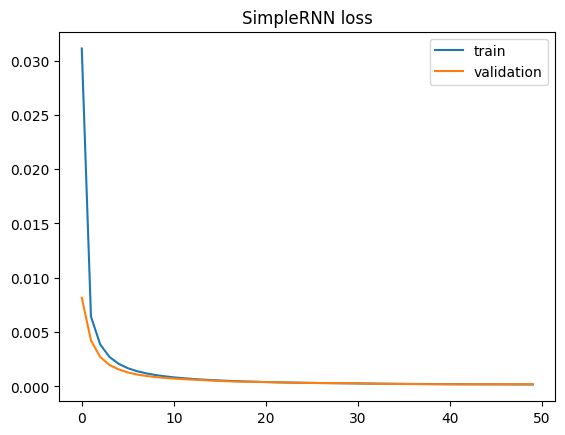

SimpleRNN test MAE: 47.9 MW   (persistence: 129.0, seasonal naive: 227.1)


In [6]:
plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="validation"); plt.legend(); plt.title("SimpleRNN loss"); plt.show()
pred_rnn = sc_y.inverse_transform(rnn.predict(X_test, verbose=0)).ravel()
mae_rnn = mean_absolute_error(y_true, pred_rnn)
print(f"SimpleRNN test MAE: {mae_rnn:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

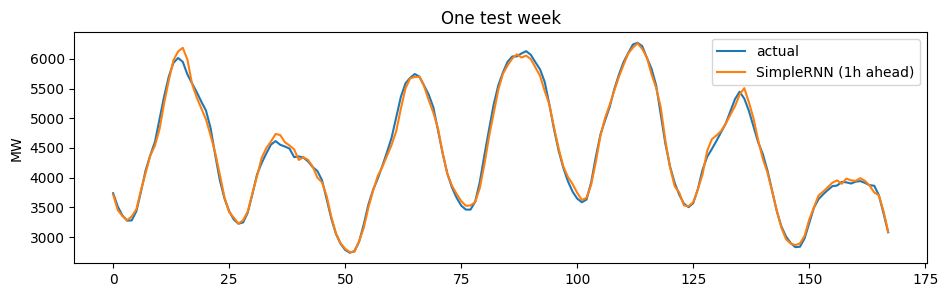

In [7]:
i0 = 24*7*28
plt.figure(figsize=(11, 3)); plt.plot(y_true[i0:i0+24*7], label="actual"); plt.plot(pred_rnn[i0:i0+24*7], label="SimpleRNN (1h ahead)")
plt.title("One test week"); plt.ylabel("MW"); plt.legend(); plt.show()

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10B — Multivariate RNN Pt 2: the LSTM swap, stacking, and a classification head
- One-word swap: SimpleRNN -> LSTM. Params x4: (8+30)*30+30 = 1,170 -> 4,680. Read it off summary().
- Stacked: return_sequences=True keeps the (24, 30) sequence for the second layer. More capacity is not automatically better - read the table.
- Bake-off table: persistence 129, seasonal naive 227, SimpleRNN ~48, LSTM ~43, stacked ~67 (worse - more capacity is not automatically better). The number to say: how much value over the dummy.
- Classification head on the SAME tensors: is this a peak hour (top 10% of training demand)? sigmoid + binary_crossentropy; majority baseline 90% so read precision/recall.
- Save -> load_model -> identical predictions. Reproducibility is a seed AND a saved artifact.
-->


## The LSTM swap, and a stacked RNN

In [8]:
lstm = Sequential([LSTM(30, input_shape=(n_steps, n_features)), Dense(1)])
lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm.summary()
lstm.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_lstm = sc_y.inverse_transform(lstm.predict(X_test, verbose=0)).ravel()
mae_lstm = mean_absolute_error(y_true, pred_lstm)
print(f"LSTM test MAE: {mae_lstm:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,711 (18.40 KB)

 Trainable params: 4,711 (18.40 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


LSTM test MAE: 43.2 MW   (persistence: 129.0, seasonal naive: 227.1)


In [9]:
stacked = Sequential([SimpleRNN(30, return_sequences=True, input_shape=(n_steps, n_features)),   # hands the whole (24, 30) sequence down
                      SimpleRNN(30),
                      Dense(1)])
stacked.compile(optimizer="adam", loss="mse", metrics=["mae"])
stacked.summary()
stacked.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_stacked = sc_y.inverse_transform(stacked.predict(X_test, verbose=0)).ravel()
mae_stacked = mean_absolute_error(y_true, pred_stacked)
print(f"stacked SimpleRNN test MAE: {mae_stacked:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 24, 30)         │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,031 (11.84 KB)

 Trainable params: 3,031 (11.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 19.


stacked SimpleRNN test MAE: 67.1 MW   (persistence: 129.0, seasonal naive: 227.1)


In [10]:
pd.Series({"mean-only": baselines.iloc[0], "seasonal naive": baselines.iloc[1], "persistence": baselines.iloc[2],
           "SimpleRNN": mae_rnn, "LSTM": mae_lstm, "stacked SimpleRNN": mae_stacked}, name="test MAE, 1h ahead (MW)").round(1)

mean-only            563.3
seasonal naive       227.1
persistence          129.0
SimpleRNN             47.9
LSTM                  43.2
stacked SimpleRNN     67.1
Name: test MAE, 1h ahead (MW), dtype: float64

## Same tensors, a classification head: is this a peak hour?

Define a peak as the **top 10% of training-set demand**. Change the head to `sigmoid`, the loss to `binary_crossentropy`, and read precision/recall - the majority-class baseline is 90%, so accuracy tells you nothing.

In [11]:
thr = train["Demand"].quantile(0.90)
peak_train = (sc_y.inverse_transform(y_train.reshape(-1, 1)).ravel() > thr).astype(int)
peak_test  = (y_true > thr).astype(int)
print(f"peak threshold: {thr:.0f} MW | peak share in test: {peak_test.mean():.1%}")

clf = Sequential([LSTM(30, input_shape=(n_steps, n_features)), Dense(1, activation="sigmoid")])
clf.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
clf.fit(X_train, peak_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
p = (clf.predict(X_test, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(peak_test, p, target_names=["normal hour", "PEAK hour"]))
print(confusion_matrix(peak_test, p))

peak threshold: 4313 MW | peak share in test: 7.4%


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 16.


              precision    recall  f1-score   support

 normal hour       0.99      0.99      0.99      8089
   PEAK hour       0.89      0.83      0.86       647

    accuracy                           0.98      8736
   macro avg       0.94      0.91      0.92      8736
weighted avg       0.98      0.98      0.98      8736

[[8024   65]
 [ 110  537]]


## Save the model and use it again

In [12]:
lstm.save('E2_Multivariate_Demand_RNN.keras')
reloaded = load_model('E2_Multivariate_Demand_RNN.keras')
print("reloaded model reproduces the predictions:", np.allclose(lstm.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Change `n_steps` to 6, then 168. Which look-back wins for one hour ahead? For the peak-hour flag?
- Add `Dropout(0.2)` after the recurrent layer. Does it help a model that is already close to persistence?
- Swap `LSTM` for `GRU` - count the parameters before you run it (G=3).